# 1. 환경 설정

## 라이브러리 설치

In [ ]:
# !pip install transformers arabert torch torchvision Pillow tqdm scikit-learn matplotlib seaborn -q

## 현재 환경 점검

In [ ]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("CPU 환경에서 실행됩니다.")

PyTorch 버전: 2.6.0+cu124
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB


# 2. 데이터 전처리

## 데이터 상태 점검

[클래스별 샘플 수]
     Angry: 291
     Happy: 303
   Neutral: 338
       Sad: 350
        합계: 1282


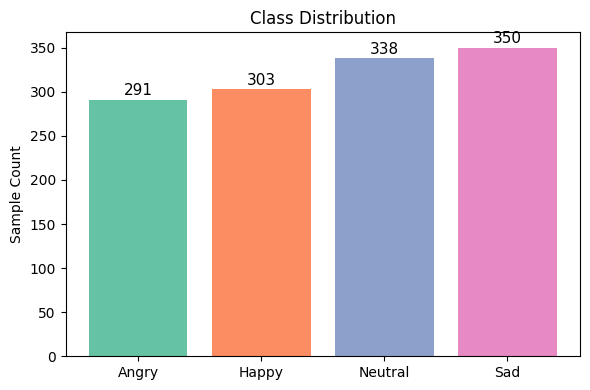

In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np

# 경로 설정 (환경에 맞게 수정)
BASE_DIR = r"C:\Honey\0406\MDER-MA Multimodal Emotion Recognition Dataset for\ERD-MA"
TEXT_DIR  = os.path.join(BASE_DIR, "ERD-MA Text")
SPEC_DIR  = os.path.join(BASE_DIR, "ERD-MA Mel-Spectrograms_")
CLASSES   = ["Angry", "Happy", "Neutral", "Sad"]

# 클래스별 샘플 수 확인
counts = {cls: len(os.listdir(os.path.join(TEXT_DIR, cls))) for cls in CLASSES}

print("[클래스별 샘플 수]")
for cls, cnt in counts.items():
    print(f"  {cls:>8}: {cnt}")
print(f"  {'합계':>8}: {sum(counts.values())}")

# 시각화
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.keys(), counts.values(), color=sns.color_palette("Set2", 4))
ax.set_title("Class Distribution")
ax.set_ylabel("Sample Count")
for i, (cls, cnt) in enumerate(counts.items()):
    ax.text(i, cnt + 5, str(cnt), ha="center", fontsize=11)
plt.tight_layout()
plt.show()

[텍스트 길이 (단어 기준)]
  평균: 12.5
  최대: 222
  95th percentile: 21


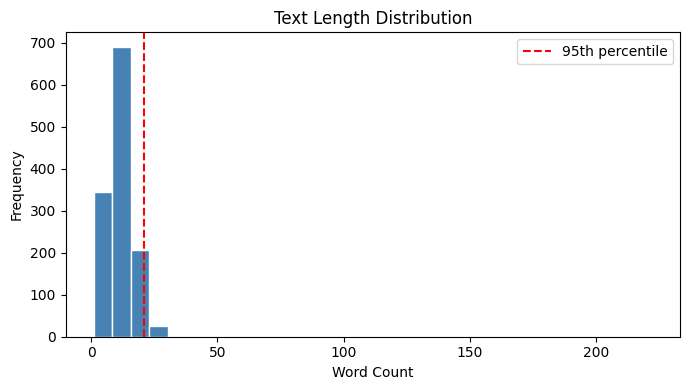

In [3]:
# 텍스트 길이 분포 확인 → AraBERT max_length 설정 근거
lengths = []
for cls in CLASSES:
    for fname in os.listdir(os.path.join(TEXT_DIR, cls)):
        with open(os.path.join(TEXT_DIR, cls, fname), "r", encoding="utf-8") as f:
            lengths.append(len(f.read().split()))

lengths = np.array(lengths)
print(f"[텍스트 길이 (단어 기준)]")
print(f"  평균: {lengths.mean():.1f}")
print(f"  최대: {lengths.max()}")
print(f"  95th percentile: {np.percentile(lengths, 95):.0f}")

plt.figure(figsize=(7, 4))
plt.hist(lengths, bins=30, color="steelblue", edgecolor="white")
plt.axvline(np.percentile(lengths, 95), color="red", linestyle="--", label="95th percentile")
plt.title("Text Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

[샘플 이미지 정보]
  크기: (1000, 400)  (W x H)
  모드: RGB


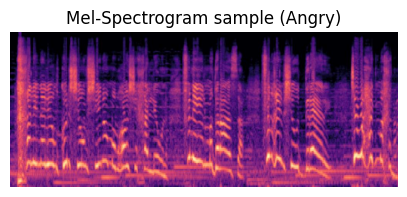

In [4]:
# 스펙트로그램 이미지 크기 확인
sample_path = os.path.join(SPEC_DIR, CLASSES[0],
                           os.listdir(os.path.join(SPEC_DIR, CLASSES[0]))[0])
img = Image.open(sample_path)

print(f"[샘플 이미지 정보]")
print(f"  크기: {img.size}  (W x H)")
print(f"  모드: {img.mode}")

plt.figure(figsize=(5, 4))
plt.imshow(img)
plt.title(f"Mel-Spectrogram sample ({CLASSES[0]})")
plt.axis("off")
plt.show()

### EDA 결과 요약 및 전처리 방향

| 항목 | 결과 | 전처리 결정 | 이유 |
|---|---|---|---|
| 클래스 분포 | Angry 291 ~ Sad 350 | Weighted Loss 적용 | 최대 1.2배 불균형, Angry 과소 표현 |
| 텍스트 길이 | 평균 12.5단어, 95th=21 | `max_length=64` | 서브워드 토크나이징 × 약 3배 여유 |
| 이미지 크기 | 1000×400 RGB | 224×224 리사이즈 | ResNet/ViT 표준 입력 크기 |

## 데이터 전처리

### 전처리 설계 근거

**텍스트**
- AraBERT(`aubmindlab/bert-base-arabertv02`) 토크나이저 사용
- `max_length=64`: EDA에서 95th percentile이 21단어 → 서브워드 토크나이징 후 여유있게 64 설정
- `padding='max_length'`, `truncation=True`: 배치 내 길이를 통일하고 극단값(max 222) 잘라냄

**이미지**
- `Resize(224, 224)`: 원본 1000×400을 ResNet/ViT 표준 입력 크기로 변환
- `Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])`: 픽셀값을 [-1, 1]로 정규화 → 사전학습 모델의 입력 분포에 맞춤

In [5]:
from transformers import AutoTokenizer
from torchvision import transforms

# ── 텍스트: AraBERT 토크나이저 ──────────────────────────────
TOKENIZER_NAME = "aubmindlab/bert-base-arabertv02"
MAX_LENGTH = 64

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

# 동작 확인
sample_txt = open(
    os.path.join(TEXT_DIR, CLASSES[0],
                 os.listdir(os.path.join(TEXT_DIR, CLASSES[0]))[0]),
    encoding="utf-8"
).read()
tokens = tokenizer(sample_txt, max_length=MAX_LENGTH,
                   padding="max_length", truncation=True, return_tensors="pt")
print(f"[텍스트 토크나이저]")
print(f"  원문: {sample_txt[:60]}...")
print(f"  input_ids shape : {tokens['input_ids'].shape}")
print(f"  attention_mask shape: {tokens['attention_mask'].shape}")

c:\Users\hubo0\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\hubo0\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hubo0\.cache\huggingface\hub\models--aubmindlab--bert-base-arabertv02. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Pytho

[텍스트 토크나이저]
  원문: الخلينا ليهم كلشي يومشينا ومبغاوش يخليونا فنهي المدرسة فنغيم...
  input_ids shape : torch.Size([1, 64])
  attention_mask shape: torch.Size([1, 64])


In [6]:
# ── 이미지: torchvision transforms ─────────────────────────
IMG_SIZE = 224

image_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # 1000×400 → 224×224
    transforms.ToTensor(),                      # [0,255] → [0,1]
    transforms.Normalize([0.5, 0.5, 0.5],      # [-1, 1] 정규화
                         [0.5, 0.5, 0.5])
])

# 동작 확인
sample_img = Image.open(sample_path).convert("RGB")
tensor_img = image_transform(sample_img)
print(f"[이미지 변환]")
print(f"  원본 크기 : {sample_img.size}")
print(f"  변환 후 shape: {tensor_img.shape}   (C x H x W)")
print(f"  값 범위   : [{tensor_img.min():.2f}, {tensor_img.max():.2f}]")

[이미지 변환]
  원본 크기 : (1000, 400)
  변환 후 shape: torch.Size([3, 224, 224])   (C x H x W)
  값 범위   : [-1.00, 1.00]


# 3. 가설 수립

텍스트와 스펙트로그램 이미지를 결합하는 방식으로 두 가지 Fusion 전략을 비교한다.

---

## Fusion A — Late Fusion

``` plain text
Text  → AraBERT → [CLS] 벡터 → Linear → logits_text
Image → ResNet  → 특징 벡터  → Linear → logits_image
                                         ↓
                               (logits_text + logits_image) / 2 → 예측
```

- 각 모달리티가 **완전히 독립적으로** 학습된 뒤 예측 단계에서만 합산
- 구조가 단순하고 안정적 → **베이스라인** 역할
- 두 모달리티 간 상호작용 학습 불가

---

## Fusion B — MBT Bottleneck Fusion

``` plain text
Text  → 토큰 시퀀스 ─┐                      ┌─ 텍스트 피처
                     ├─ [Early] 각자 독립 학습 ─┤
Image → 패치 시퀀스 ─┘                      └─ 이미지 피처
                              ↓ Fusion Layer 도달
              [병목 토큰] ←→ 텍스트/이미지 토큰과 Attention
              병목 토큰 = (텍스트측 업데이트 + 이미지측 업데이트) / 2
                              ↓
                        최종 분류 헤드 → 예측
```

- **소수의 병목 토큰**이 두 모달리티 간 정보 교환 담당 (직접 교류 없음)
- 모달리티 간 상호작용을 학습하면서도 연산량 절감
- 참고: Nagrani et al., *Attention Bottlenecks for Multimodal Fusion*, NeurIPS 2021

---

**가설**: 단순 Late Fusion보다 MBT Bottleneck Fusion이 텍스트-이미지 간 감정 정보를 더 효과적으로 결합하여 높은 분류 성능을 보일 것이다.